In [11]:
from spectral_spatial_simulation import LookupTableWET
from prettyconsole import Console
import numpy as np
import matplotlib.pyplot as plt

# Try to reproduce Fig. 3b in WET paper
### Flexible

In [12]:

def for_fig_3b_paper(flip_angles: list):
    
    # Fixed input variables for the Bloch Simulation
    TR = 3000  #TR = 600   # [ms]
    TE = 0     # [ms]
    T2 = 250   # [ms] # HAS NO EFFECT HERE!!!!
    flip_angle_excitation = 47.0           # [°] # Why exactly this flip angle?
    flip_angles_WET = flip_angles          #flip_angles_WET = [75.8, 70.5, 118.8]  # [°] Why exactly this flip angles? -> paper!
    time_gaps_WET = [60] * int(len(flip_angles)) # time_gaps_WET = [60, 60, 60]           # [ms]
    
    # Variables containing range for generating the dictionary
    T1_step_size = 1       # | This only creates one value T1 value in an array!    #T1_step_size = 50      # [ms]
    T1_range = [800, 800]  # |   --- belongs to line above ---                      #T1_range = [300, 5000] # [ms]
    
    # What is this?
    B1_scales_inhomogeneity = [0.7, 1.3]      #B1_scales_inhomogeneity = [1e-10,3] # Maybe this is the possible range due to the inhomogeneities?
    B1_scales_gauss = [0.7, 1.3]              #B1_scales_gauss = [0.01, 1]         # Maybe this is the possible range of the gauss excitation pulse?
    B1_scales_inhomogeneity_step_size=0.01    #B1_scales_inhomogeneity_step_size = 0.05
    B1_scales_gauss_step_size=0.01            #B1_scales_gauss_step_size=0.05
    
    
    #   Generate B1 values (scaling values) vector
    #B1_scales_lower_border = np.min([B1_scales_gauss[0], B1_scales_inhomogeneity[0]])
    #B1_scales_upper_border = np.max([B1_scales_gauss[1], B1_scales_inhomogeneity[1]])
    #B1_scales_step_size = np.min([B1_scales_inhomogeneity_step_size, B1_scales_gauss_step_size])
    #B1_scales_effective_values = np.arange(
    #    B1_scales_lower_border,                           # lower border
    #    B1_scales_upper_border+B1_scales_step_size, # upper border, not inclusive (see math) and thus + step size
    #    B1_scales_step_size                               # the step size
    #)
    
    #x = 100*(B1_scales_effective_values - 1)
    # This happens internally ==> TAKE CARE THAT IT IS REPRODUCED PROPERLY HERE (!!!)
    #B1_scales_effective_values = np.arange(0.9, 1.1 + 0.02, 0.02)
    B1_scales_effective_values = np.arange(0.7, 1.3 + 0.01, 0.01)
    x = 100 * (B1_scales_effective_values - 1)
    
    
    off_resonance=0
    
    # To simulate the evolution of M = (Mx, My, Mz) of a spin system during a WET sequence + final excitation pulse.
    lookup_table_WET_test = LookupTableWET(T1_range=T1_range,                      #### TODO: describe each of them
                                           T1_step_size=T1_step_size,
                                           T2=T2,
                                           B1_scales_inhomogeneity=B1_scales_inhomogeneity, # TODO
                                           B1_scales_gauss=B1_scales_gauss,
                                           B1_scales_inhomogeneity_step_size=B1_scales_inhomogeneity_step_size,
                                           B1_scales_gauss_step_size=B1_scales_gauss_step_size,
                                           TR=TR,
                                           TE=TE, # TODO -> why 0???
                                           flip_angle_excitation_degree=flip_angle_excitation,
                                           flip_angles_WET_degree=flip_angles_WET,
                                           time_gaps_WET=time_gaps_WET,
                                           off_resonance=off_resonance)
    
    lookup_table_WET_test.create()

    y = lookup_table_WET_test.residual_long_mag

    return x, y

[ 37  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.010 | Range:  0.700: 1.300
                       => Axis 2: T1/TR    | Resolution:  0.000 | Range:  0.267: 0.267


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 20.34it/s]


[ 38  ][ success ] >> Created WET lookup table with 62 entries. Values Range: [0.005644650925364325, 0.4482586537294207]   
[ 39  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.010 | Range:  0.700: 1.300
                       => Axis 2: T1/TR    | Resolution:  0.000 | Range:  0.267: 0.267


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 20.25it/s]


[ 40  ][ success ] >> Created WET lookup table with 62 entries. Values Range: [0.000429307903344705, 0.19315684154322998]  
[ 41  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.010 | Range:  0.700: 1.300
                       => Axis 2: T1/TR    | Resolution:  0.000 | Range:  0.267: 0.267


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 17.35it/s]


[ 42  ][ success ] ---v  (automatic line breaks) 
                      Created WET lookup table with 62 entries. Values Range: [0.00020575149160334657,
                      0.12178105662156827]
[ 43  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.010 | Range:  0.700: 1.300
                       => Axis 2: T1/TR    | Resolution:  0.000 | Range:  0.267: 0.267


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 15.27it/s]


[ 44  ][ success ] ---v  (automatic line breaks) 
                      Created WET lookup table with 62 entries. Values Range: [1.7971899581161225e-05,
                      0.031329083921684625]


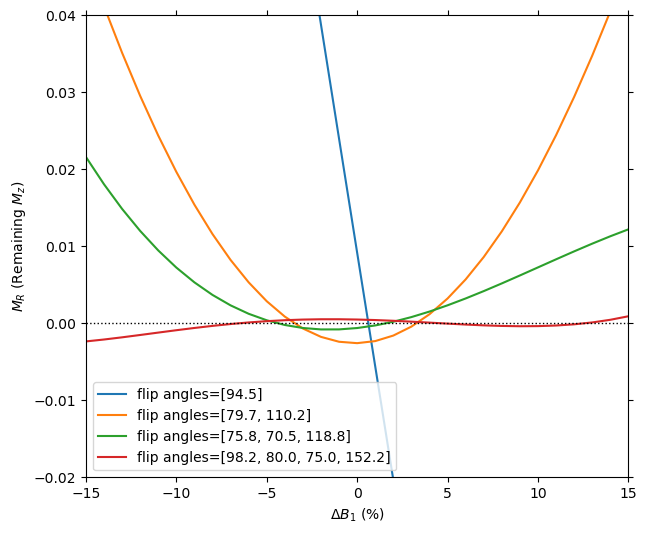

In [13]:
x_1, y_1 = for_fig_3b_paper([94])
x_2, y_2 = for_fig_3b_paper([79.7, 110.2])
x_3, y_3 = for_fig_3b_paper([75.8, 70.5, 118.8])
x_4, y_4 = for_fig_3b_paper([98.2, 80.0, 75.0, 152.2])

plt.figure(figsize=(7, 6))
plt.plot(x_1, y_1, label="flip angles=[94.5]")
plt.plot(x_2, y_2, label="flip angles=[79.7, 110.2]")
plt.plot(x_3, y_3, label="flip angles=[75.8, 70.5, 118.8]")
plt.plot(x_4, y_4, label="flip angles=[98.2, 80.0, 75.0, 152.2]")
plt.ylim([-0.02, 0.04])
plt.xlim([-15, 15])
plt.axhline(
    y=0,
    linewidth=1,     # thinner
    color='black',     # black
    linestyle=':'      # dotted
)
plt.xlabel("$Δ B_1$ (%)")
plt.ylabel("$M_R$ (Remaining $M_z$)")
plt.tick_params(top=True, right=True)
plt.legend()
plt.show()

# Try to reproduce Fig. 3a

In [7]:

def for_fig_3a_paper(flip_angles: list):
    
    # Fixed input variables for the Bloch Simulation
    TR = 3000  #TR = 600   # [ms]
    TE = 0     # [ms]
    T2 = 250   # [ms] # HAS NO EFFECT HERE!!!!
    flip_angle_excitation = 47.0           # [°] # Why exactly this flip angle?
    flip_angles_WET = flip_angles          #flip_angles_WET = [75.8, 70.5, 118.8]  # [°] Why exactly this flip angles? -> paper!
    time_gaps_WET = [60] * int(len(flip_angles)) # time_gaps_WET = [60, 60, 60]           # [ms]
    
    # Variables containing range for generating the dictionary
    T1_step_size = 10       # | This only creates one value T1 value in an array!    #T1_step_size = 50      # [ms]
    T1_range = [10, 3000]   # |   --- belongs to line above ---                      #T1_range = [300, 5000] # [ms]
    
    # What is this?
    B1_scales_inhomogeneity = [1.0, 1.0]   #B1_scales_inhomogeneity = [0.7, 1.3]      #B1_scales_inhomogeneity = [1e-10,3] # Maybe this is the possible range due to the inhomogeneities?
    B1_scales_gauss = [1.0, 1.0]           #B1_scales_gauss = [0.7, 1.3]              #B1_scales_gauss = [0.01, 1]         # Maybe this is the possible range of the gauss excitation pulse?
    B1_scales_inhomogeneity_step_size=1    #B1_scales_inhomogeneity_step_size=0.02    #B1_scales_inhomogeneity_step_size = 0.05
    B1_scales_gauss_step_size=1            #B1_scales_gauss_step_size=0.02            #B1_scales_gauss_step_size=0.05
    
    
    #   Generate B1 values (scaling values) vector
    #B1_scales_lower_border = np.min([B1_scales_gauss[0], B1_scales_inhomogeneity[0]])
    #B1_scales_upper_border = np.max([B1_scales_gauss[1], B1_scales_inhomogeneity[1]])
    #B1_scales_step_size = np.min([B1_scales_inhomogeneity_step_size, B1_scales_gauss_step_size])
    #B1_scales_effective_values = np.arange(
    #    B1_scales_lower_border,                           # lower border
    #    B1_scales_upper_border+B1_scales_step_size, # upper border, not inclusive (see math) and thus + step size
    #    B1_scales_step_size                               # the step size
    #)
    
    #x = 100*(B1_scales_effective_values - 1)
    # This happens internally ==> TAKE CARE THAT IT IS REPRODUCED PROPERLY HERE (!!!)
    #B1_scales_effective_values = np.arange(0.9, 1.1 + 0.02, 0.02)
    #B1_scales_effective_values = np.arange(0.7, 1.3 + 0.02, 0.02)
    #x = 100 * (B1_scales_effective_values - 1)

    x = np.linspace(T1_range[0], T1_range[1], 300) /1000.0 # to bring in sec

    
    off_resonance=0
    
    # To simulate the evolution of M = (Mx, My, Mz) of a spin system during a WET sequence + final excitation pulse.
    lookup_table_WET_test = LookupTableWET(T1_range=T1_range,                      #### TODO: describe each of them
                                           T1_step_size=T1_step_size,
                                           T2=T2,
                                           B1_scales_inhomogeneity=B1_scales_inhomogeneity, # TODO
                                           B1_scales_gauss=B1_scales_gauss,
                                           B1_scales_inhomogeneity_step_size=B1_scales_inhomogeneity_step_size,
                                           B1_scales_gauss_step_size=B1_scales_gauss_step_size,
                                           TR=TR,
                                           TE=TE, # TODO -> why 0???
                                           flip_angle_excitation_degree=flip_angle_excitation,
                                           flip_angles_WET_degree=flip_angles_WET,
                                           time_gaps_WET=time_gaps_WET,
                                           off_resonance=off_resonance)
    
    lookup_table_WET_test.create()

    y = lookup_table_WET_test.residual_long_mag

    return x, y

[ 17  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.000: 1.000
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|███████████████████████████████████████| 300/300 [00:00<00:00, 1506.86it/s]


[ 18  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [0.0003458258184700995, 0.9973267671690189] 
[ 19  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.000: 1.000
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|███████████████████████████████████████| 300/300 [00:00<00:00, 1244.42it/s]


[ 20  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [3.821030825028243e-05, 0.9950485755181553] 
[ 21  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.000: 1.000
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|███████████████████████████████████████| 300/300 [00:00<00:00, 1078.08it/s]


[ 22  ][ success ] ---v  (automatic line breaks) 
                      Created WET lookup table with 300 entries. Values Range: [1.2280442549905692e-06,
                      0.9950471988396085]
[ 23  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.000: 1.000
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|████████████████████████████████████████| 300/300 [00:00<00:00, 950.00it/s]


[ 24  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [9.757481492739432e-06, 0.9950466365180022] 


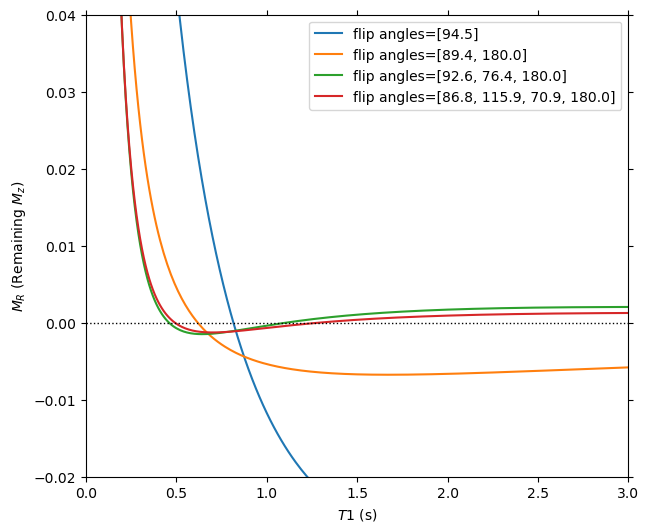

In [8]:
x_1, y_1 = for_fig_3a_paper([94.5])
x_2, y_2 = for_fig_3a_paper([89.4, 180.0])
x_3, y_3 = for_fig_3a_paper([92.6, 76.4, 180.0])
x_4, y_4 = for_fig_3a_paper([86.8, 115.9, 70.9, 180.0])

plt.figure(figsize=(7, 6))
plt.plot(x_1, y_1, label="flip angles=[94.5]")
plt.plot(x_2, y_2, label="flip angles=[89.4, 180.0]")
plt.plot(x_3, y_3, label="flip angles=[92.6, 76.4, 180.0]")
plt.plot(x_4, y_4, label="flip angles=[86.8, 115.9, 70.9, 180.0]")
plt.ylim([-0.02, 0.04])
plt.xlim([0,3])
plt.axhline(
    y=0,
    linewidth=1,     # thinner
    color='black',     # black
    linestyle=':'      # dotted
)
plt.xlabel("$T1$ (s)")
plt.ylabel("$M_R$ (Remaining $M_z$)")
plt.tick_params(top=True, right=True)
plt.legend()
plt.show()

# Try to reproduce Fig. 4a

In [9]:
def for_fig_4a_paper(B1_scale, flip_angles):
    
    # Fixed input variables for the Bloch Simulation
    TR = 3000  #TR = 600   # [ms]
    TE = 0     # [ms]
    T2 = 250   # [ms] # HAS NO EFFECT HERE!!!!
    flip_angle_excitation = 47.0           # [°] # Why exactly this flip angle?
    flip_angles_WET = flip_angles          #flip_angles_WET = [75.8, 70.5, 118.8]  # [°] Why exactly this flip angles? -> paper!
    time_gaps_WET = [60] * int(len(flip_angles)) # time_gaps_WET = [60, 60, 60]           # [ms]
    
    # Variables containing range for generating the dictionary
    T1_step_size = 10       # | This only creates one value T1 value in an array!    #T1_step_size = 50      # [ms]
    T1_range = [10, 3000]   # |   --- belongs to line above ---                      #T1_range = [300, 5000] # [ms]
    
    # What is this?
    B1_scales_inhomogeneity = [B1_scale, B1_scale]   #B1_scales_inhomogeneity = [0.7, 1.3]      #B1_scales_inhomogeneity = [1e-10,3] # Maybe this is the possible range due to the inhomogeneities?
    B1_scales_gauss = [B1_scale, B1_scale]           #B1_scales_gauss = [0.7, 1.3]              #B1_scales_gauss = [0.01, 1]         # Maybe this is the possible range of the gauss excitation pulse?
    B1_scales_inhomogeneity_step_size=1    #B1_scales_inhomogeneity_step_size=0.02    #B1_scales_inhomogeneity_step_size = 0.05
    B1_scales_gauss_step_size=1            #B1_scales_gauss_step_size=0.02            #B1_scales_gauss_step_size=0.05
    
    
    #   Generate B1 values (scaling values) vector
    #B1_scales_lower_border = np.min([B1_scales_gauss[0], B1_scales_inhomogeneity[0]])
    #B1_scales_upper_border = np.max([B1_scales_gauss[1], B1_scales_inhomogeneity[1]])
    #B1_scales_step_size = np.min([B1_scales_inhomogeneity_step_size, B1_scales_gauss_step_size])
    #B1_scales_effective_values = np.arange(
    #    B1_scales_lower_border,                           # lower border
    #    B1_scales_upper_border+B1_scales_step_size, # upper border, not inclusive (see math) and thus + step size
    #    B1_scales_step_size                               # the step size
    #)
    
    #x = 100*(B1_scales_effective_values - 1)
    # This happens internally ==> TAKE CARE THAT IT IS REPRODUCED PROPERLY HERE (!!!)
    #B1_scales_effective_values = np.arange(0.9, 1.1 + 0.02, 0.02)
    #B1_scales_effective_values = np.arange(0.7, 1.3 + 0.02, 0.02)
    #x = 100 * (B1_scales_effective_values - 1)

    x = np.linspace(T1_range[0], T1_range[1], 300) /1000.0 # to bring in sec

    
    off_resonance=0
    
    # To simulate the evolution of M = (Mx, My, Mz) of a spin system during a WET sequence + final excitation pulse.
    lookup_table_WET_test = LookupTableWET(T1_range=T1_range,                      #### TODO: describe each of them
                                           T1_step_size=T1_step_size,
                                           T2=T2,
                                           B1_scales_inhomogeneity=B1_scales_inhomogeneity, # TODO
                                           B1_scales_gauss=B1_scales_gauss,
                                           B1_scales_inhomogeneity_step_size=B1_scales_inhomogeneity_step_size,
                                           B1_scales_gauss_step_size=B1_scales_gauss_step_size,
                                           TR=TR,
                                           TE=TE, # TODO -> why 0???
                                           flip_angle_excitation_degree=flip_angle_excitation,
                                           flip_angles_WET_degree=flip_angles_WET,
                                           time_gaps_WET=time_gaps_WET,
                                           off_resonance=off_resonance)
    
    lookup_table_WET_test.create()

    y = lookup_table_WET_test.residual_long_mag

    return x, y

[ 57  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.000: 1.000
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|████████████████████████████████████████| 300/300 [00:00<00:00, 948.48it/s]


[ 58  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [9.687445239261007e-06, 0.9951813036565885] 
[ 59  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  1.100: 1.100
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|████████████████████████████████████████| 300/300 [00:00<00:00, 948.94it/s]


[ 60  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [2.064464857858628e-05, 0.9950503507302407] 
[ 61  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  0.900: 0.900
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


...

100%|███████████████████████████████████████| 300/300 [00:00<00:00, 1497.71it/s]


[ 66  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [0.0016883576941480705, 0.9969236824915538] 
[ 67  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  1.000 | Range:  0.900: 0.900
                       => Axis 2: T1/TR    | Resolution:  0.003 | Range:  0.003: 1.000


100%|███████████████████████████████████████| 300/300 [00:00<00:00, 1521.02it/s]


[ 68  ][ success ] >> Created WET lookup table with 300 entries. Values Range: [0.08565356399210144, 0.9977351303403719]   


(0.0, 3.0)

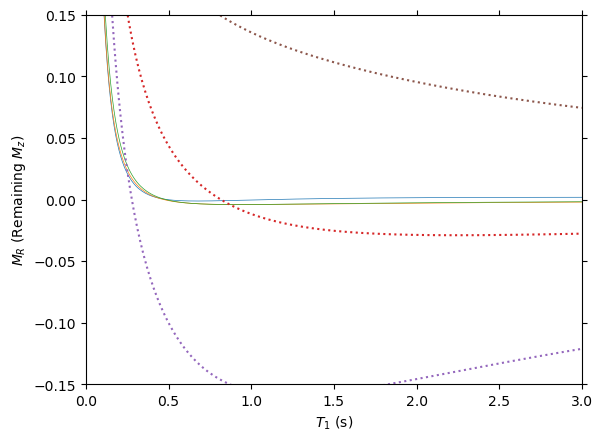

In [15]:
x_nom__4_pulse, y_nom__4_pulse = for_fig_4a_paper(B1_scale=1, flip_angles=[81.4, 101.4, 69.3, 161.0])
x_nom_plus_10__4_pulse, y_nom_plus_10__4_pulse = for_fig_4a_paper(B1_scale=1+0.1, flip_angles=[81.4, 101.4, 69.3, 161.0])
x_nom_minus_10__4_pulse, y_nom_minus_10__4_pulse = for_fig_4a_paper(B1_scale=1-0.1, flip_angles=[81.4, 101.4, 69.3, 161.0])

x_nom__1_pulse, y_nom__1_pulse = for_fig_4a_paper(B1_scale=1, flip_angles=[94.5])
x_nom_plus_10__1_pulse, y_nom_plus_10__1_pulse = for_fig_4a_paper(B1_scale=1+0.1, flip_angles=[94.5])
x_nom_minus_10__1_pulse, y_nom_minus_10__1_pulse = for_fig_4a_paper(B1_scale=1-0.1, flip_angles=[94.5])


plt.plot(x_nom__4_pulse, y_nom__4_pulse, lw=0.5, label="nominal $B_1$ (4 Pulses)")
plt.plot(x_nom_plus_10__4_pulse, y_nom_plus_10__4_pulse, lw=0.5, label="+10% $B_1$ (4 Pulses)")
plt.plot(x_nom_minus_10__4_pulse, y_nom_minus_10__4_pulse, lw=0.5, label="-10% $B_1$ (4 Pulses)")

plt.plot(x_nom__1_pulse, y_nom__1_pulse, label="nominal $B_1$ (1 Pulse)", linestyle=':')
plt.plot(x_nom_plus_10__1_pulse, y_nom_plus_10__1_pulse, label="+10% $B_1$ (1 Pulse)", linestyle=':')
plt.plot(x_nom_minus_10__1_pulse, y_nom_minus_10__1_pulse, label="-10% $B_1$ (1 Pulse)", linestyle=':')

#plt.legend(ncol=2)
plt.tick_params(top=True, right=True)

plt.xlabel("$T_1$ (s)")
plt.ylabel("$M_R$ (Remaining $M_z$)")

plt.ylim([-0.15, 0.15])
plt.xlim([0,3])